In [20]:
import numpy as np
import matplotlib.pyplot as plt

1)

2) a)

In [21]:
def gamma(n):
    result = 1
    for i in range(1, int(n)):
        result *= i
    return result

def beta_func(a, b): #beta function
    return gamma(a) * gamma(b) / gamma (a + b)

def beta_dist(theta, alpha, beta): #beta distribution
    return (theta ** (alpha - 1) * (1 - theta) ** (beta - 1)) / beta_func(alpha, beta)

def binomial (data, theta): #binomial likelihood
    heads = np.sum(data)
    tails = len(data) - heads
    return (theta ** heads) * ((1 - theta) ** tails)

def bayesian (prior_func, likelihood_func, data, thetas):
    prior = np.array([prior_func(t) for t in thetas])
    likelihood = np.array([likelihood_func(data, t) for t in thetas])

    unnormalized = likelihood * prior

    #used trapezoidal rule to normalize so it integrates to 1
    normalization = np.trapz(unnormalized, thetas)
    posterior = unnormalized / normalization
    
    return posterior

2) b)

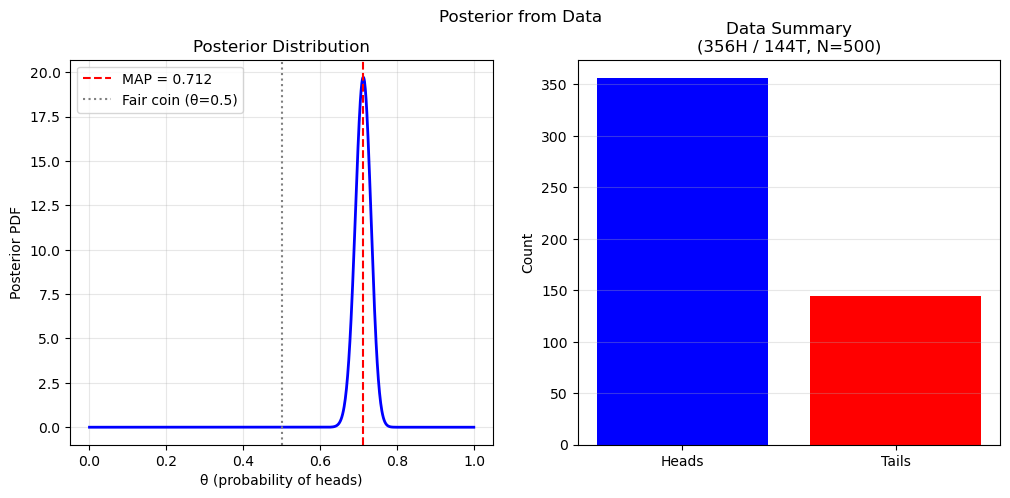

In [26]:
data = np.loadtxt('HW06_data.txt')
thetas = np.linspace(0.001, 0.999, 1000)

prior_func = lambda t: beta_dist(t, 1, 1)
posterior = bayesian (prior_func, binomial, data, thetas)

heads = int(np.sum(data))
tails = int(len(data) - heads)
map_estimate = thetas[np.argmax(posterior)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle ("Posterior from Data")

axes[0].plot(thetas, posterior, color='blue', linewidth=2)
axes[0].axvline(map_estimate, color='red', linestyle='--', label=f'MAP = {map_estimate:.3f}')
axes[0].axvline(0.5, color='gray', linestyle=':', label='Fair coin (θ=0.5)')
axes[0].set_xlabel('θ (probability of heads)')
axes[0].set_ylabel('Posterior PDF')
axes[0].set_title('Posterior Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(['Heads', 'Tails'], [heads, tails], color=['blue', 'red'])
axes[1].set_title(f'Data Summary\n({heads}H / {tails}T, N={len(data)})')
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.3, axis='y')

plt.show()

2) c) 

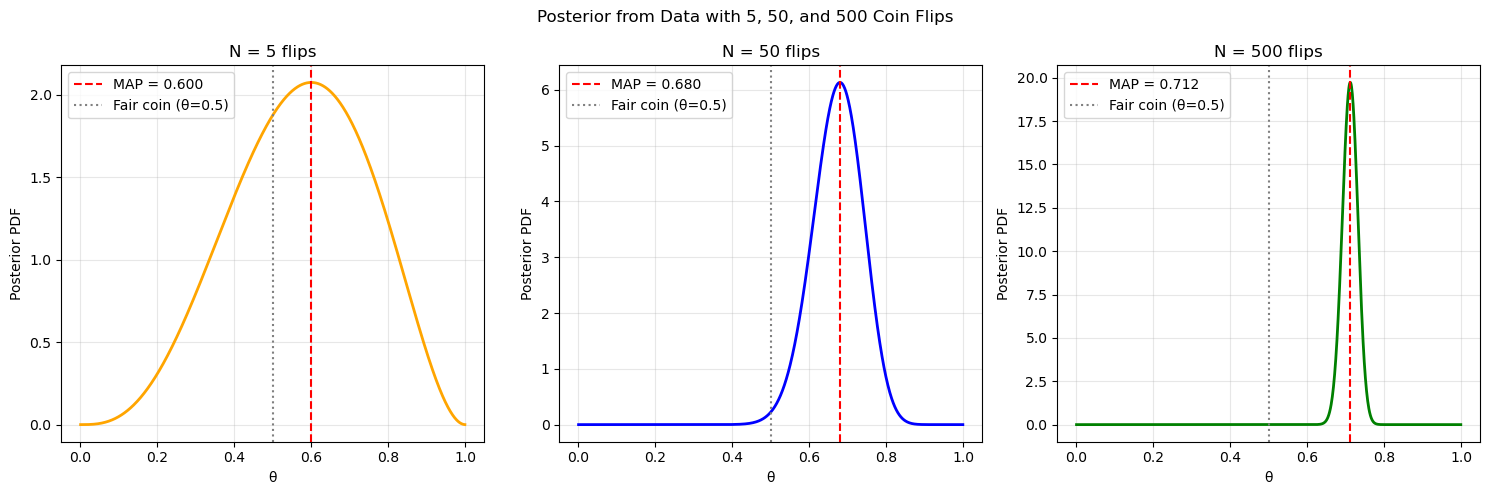

In [38]:
all_data = np.loadtxt('HW06_data.txt')
thetas = np.linspace(0.001, 0.999, 1000)

prior_func = lambda t: beta_dist(t, 1, 1)
sizes = [5, 50, 500]
colors = ['orange', 'blue', 'green']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle ("Posterior from Data with 5, 50, and 500 Coin Flips")


for ax, n, color in zip(axes, sizes, colors):
    data_subset = all_data[:n]
    posterior = bayesian (prior_func, binomial, data_subset, thetas)

    map_est = thetas[np.argmax(posterior)]

    ax.plot(thetas, posterior, color=color, linewidth=2)
    ax.axvline(map_est, color='red', linestyle='--', label=f'MAP = {map_est:.3f}')
    ax.axvline(0.5, color='gray', linestyle=':', label='Fair coin (θ=0.5)')
    ax.set_title(f'N = {n} flips')
    ax.set_xlabel('θ')
    ax.set_ylabel('Posterior PDF')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

2) d) 

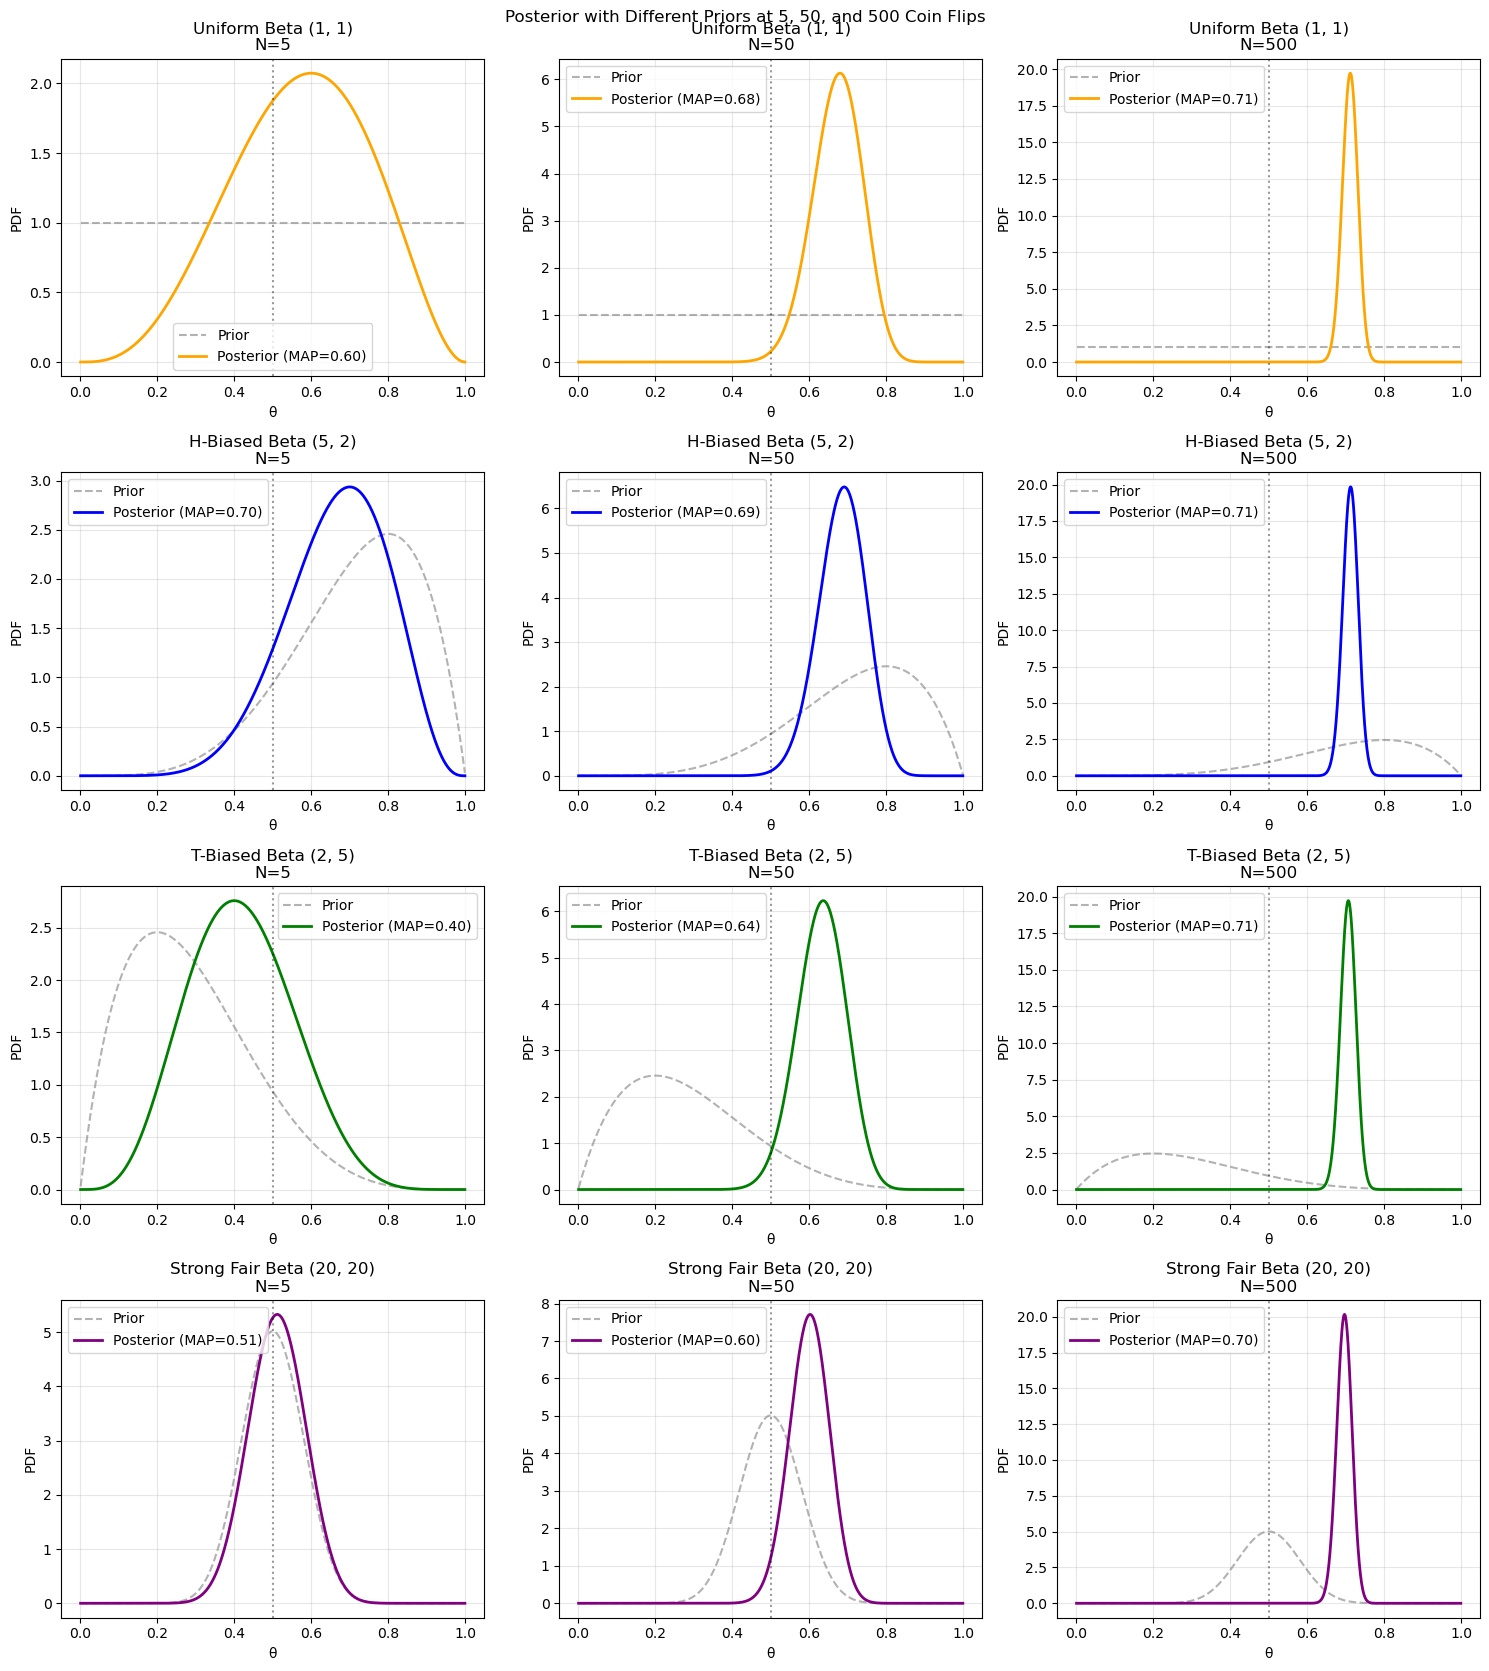

In [47]:
all_data = np.loadtxt('HW06_data.txt')
thetas = np.linspace(0.001, 0.999, 1000)

priors = {
    "Uniform Beta (1, 1)": (1, 1), 
    "H-Biased Beta (5, 2)": (5, 2),
    "T-Biased Beta (2, 5)": (2, 5),
    "Strong Fair Beta (20, 20)": (20, 20),
}

sizes = [5, 50, 500]
colors = ['orange', 'blue', 'green', 'purple']

fig, axes = plt.subplots(len(priors), 3, figsize=(15, 17))
fig.suptitle ("Posterior with Different Priors at 5, 50, and 500 Coin Flips")


for row, ((label, (a, b)), color) in enumerate(zip(priors.items(), colors)):
    prior_func = lambda t, a=a, b=b: beta_dist(t, a, b)
    for col, n in enumerate(sizes):
        ax = axes[row][col]
        data_subset = all_data[:n]
        posterior = bayesian (prior_func, binomial, data_subset, thetas)
        prior_vals = np.array([prior_func(t) for t in thetas])
        map_est = thetas[np.argmax(posterior)]

        ax.plot(thetas, prior_vals, 'gray', linewidth=1.5, linestyle='--', label='Prior', alpha=0.6)
        ax.plot(thetas, posterior, color=color, linewidth=2, label=f'Posterior (MAP={map_est:.2f})')
        ax.axvline(0.5, color='black', linestyle=':', alpha=0.4)
        ax.set_title(f'{label}\nN={n}')
        ax.set_xlabel('θ')
        ax.set_ylabel('PDF')
        ax.legend()
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

3) a)

In [41]:
np.random.seed(55)
N = 100
x = np.random.uniform(0, 1, N)
y = np.random.uniform(0, 1, N)

#inside quarter circle if x^2 + y^2 <= 1
inside = (x**2 + y**2) <= 1
data_circle = inside.astype(int) # 1 = inside, 0 = outside

print(f"Points inside quarter circle: {np.sum(inside)} / {N}")

Points inside quarter circle: 82 / 100


3) b) 

MAP estimate of theta:  0.8202
Estimated pi: 3.2807
Relative error: 4.43%


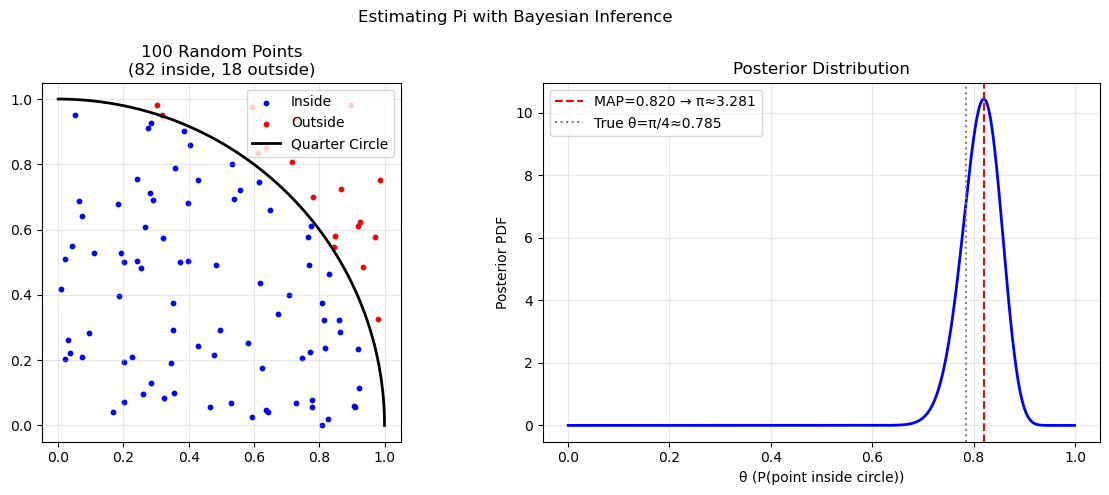

In [45]:
thetas = np.linspace(0.001, 0.999, 1000)
prior_func = lambda t: beta_dist(t, 1, 1)  # uniform prior
posterior = bayesian(prior_func, binomial, data_circle, thetas)

map_est = thetas[np.argmax(posterior)]
pi_estimate = 4 * map_est

print(f"MAP estimate of theta: {map_est: .4f}")
print(f"Estimated pi: {pi_estimate:.4f}")
print(f"Relative error: {abs(pi_estimate - np.pi) / np.pi * 100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize = (12, 5))
fig.suptitle("Estimating Pi with Bayesian Inference")

axes[0].scatter(x[inside], y[inside], color = 'blue', s=10, label = 'Inside')
axes[0].scatter(x[~inside], y[~inside], color = 'red', s = 10, label = 'Outside')
axes[0].set_aspect('equal')
theta_arc = np.linspace(0, np.pi/2, 300)
axes[0].plot(np.cos(theta_arc), np.sin(theta_arc), 'k-', linewidth = 2, label = 'Quarter Circle')
axes[0].set_title(f'100 Random Points\n({np.sum(inside)} inside, {N - np.sum(inside)} outside)')
axes[0].legend()
axes[0].grid(alpha = 0.3)

axes[1].plot(thetas, posterior, color = "blue", linewidth = 2)
axes[1].axvline(map_est, color='red', linestyle='--', label=f'MAP={map_est:.3f} → π≈{pi_estimate:.3f}')
axes[1].axvline(np.pi/4, color='gray', linestyle=':', label=f'True θ=π/4≈{np.pi/4:.3f}')
axes[1].set_xlabel('θ (P(point inside circle))')
axes[1].set_ylabel('Posterior PDF')
axes[1].set_title('Posterior Distribution')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

3) c) 

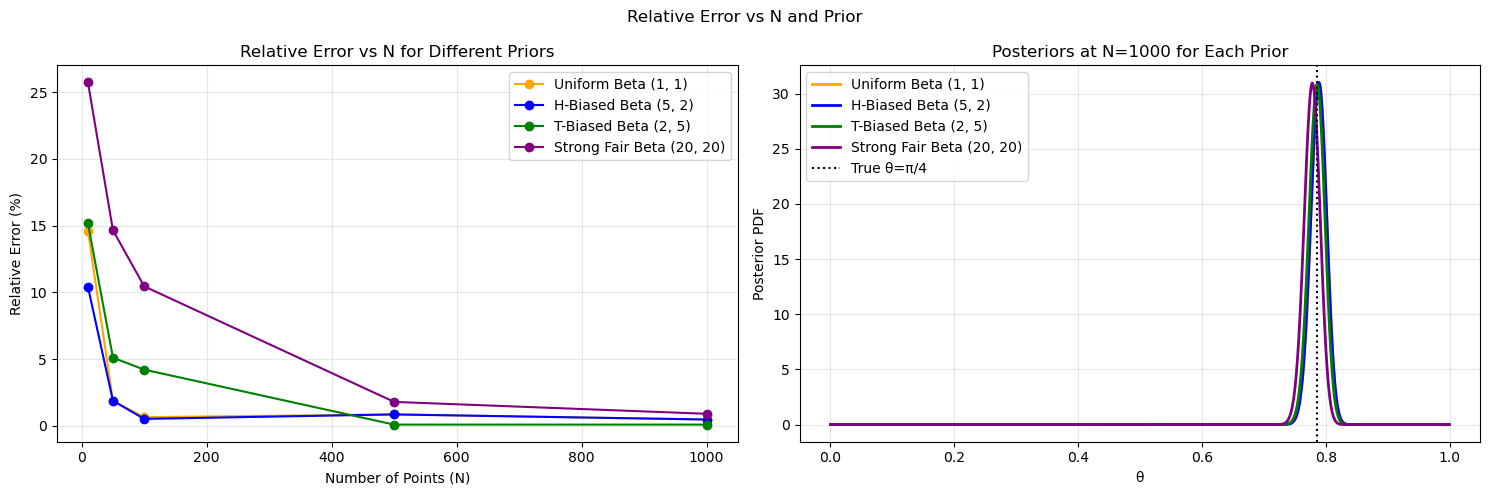

In [49]:
priors = {
    "Uniform Beta (1, 1)": (1, 1), 
    "H-Biased Beta (5, 2)": (5, 2),
    "T-Biased Beta (2, 5)": (2, 5),
    "Strong Fair Beta (20, 20)": (20, 20),
}

sizes = [10, 50, 100, 500, 1000]
colors = ['orange', 'blue', 'green', 'purple']

np.random.seed(55)
N_max = 1000
x = np.random.uniform(0, 1, N_max)
y = np.random.uniform(0, 1, N_max)

#inside quarter circle if x^2 + y^2 <= 1
inside = (x**2 + y**2) <= 1
data_all = inside.astype(int) # 1 = inside, 0 = outside

fig, axes = plt.subplots(1, 2, figsize = (15, 5))
fig.suptitle("Relative Error vs N and Prior")

for (label, (a, b)), color in zip(priors.items(), colors):
    prior_func_c = lambda t, a=a, b=b: beta_dist(t, a, b)
    errors = []
    for n in sizes:
        subset = data_all[:n]
        post = bayesian(prior_func_c, binomial, subset, thetas)
        map_n = thetas[np.argmax(post)]
        pi_est = 4 * map_n
        errors.append(abs(pi_est - np.pi) / np.pi * 100)
    axes[0].plot(sizes, errors, marker='o', label=label, color=color)

axes[0].set_xlabel('Number of Points (N)')
axes[0].set_ylabel('Relative Error (%)')
axes[0].set_title('Relative Error vs N for Different Priors')
axes[0].legend()
axes[0].grid(alpha=0.3)

for (label, (a, b)), color in zip(priors.items(), colors):
    prior_func_c = lambda t, a=a, b=b: beta_dist(t, a, b)
    post = bayesian(prior_func_c, binomial, data_all, thetas)
    axes[1].plot(thetas, post, color=color, linewidth=2, label=label)

axes[1].axvline(np.pi/4, color='black', linestyle=':', label=f'True θ=π/4')
axes[1].set_xlabel('θ')
axes[1].set_ylabel('Posterior PDF')
axes[1].set_title('Posteriors at N=1000 for Each Prior')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
